# Step 3 — 正常訂單瓶頸拆解

**目標**：排除異常後，分析正常訂單的 phase breakdown

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
order_flags = pd.read_csv('../data/order_flags.csv')
df = df.merge(order_flags, on='order_id')

normal = df[~(df['is_system_anomaly'] | df['is_user_anomaly'])].copy()
print(f"Total: {len(df):,}, Normal: {len(normal):,} ({100*len(normal)/len(df):.1f}%)")


Total: 30,000, Normal: 29,674 (98.9%)


## Phase Estimation + Model Validation

Orders per group:
fc_group
<100         13184
100-1000     15067
1000-2000      865
2000+          558
Name: count, dtype: int64


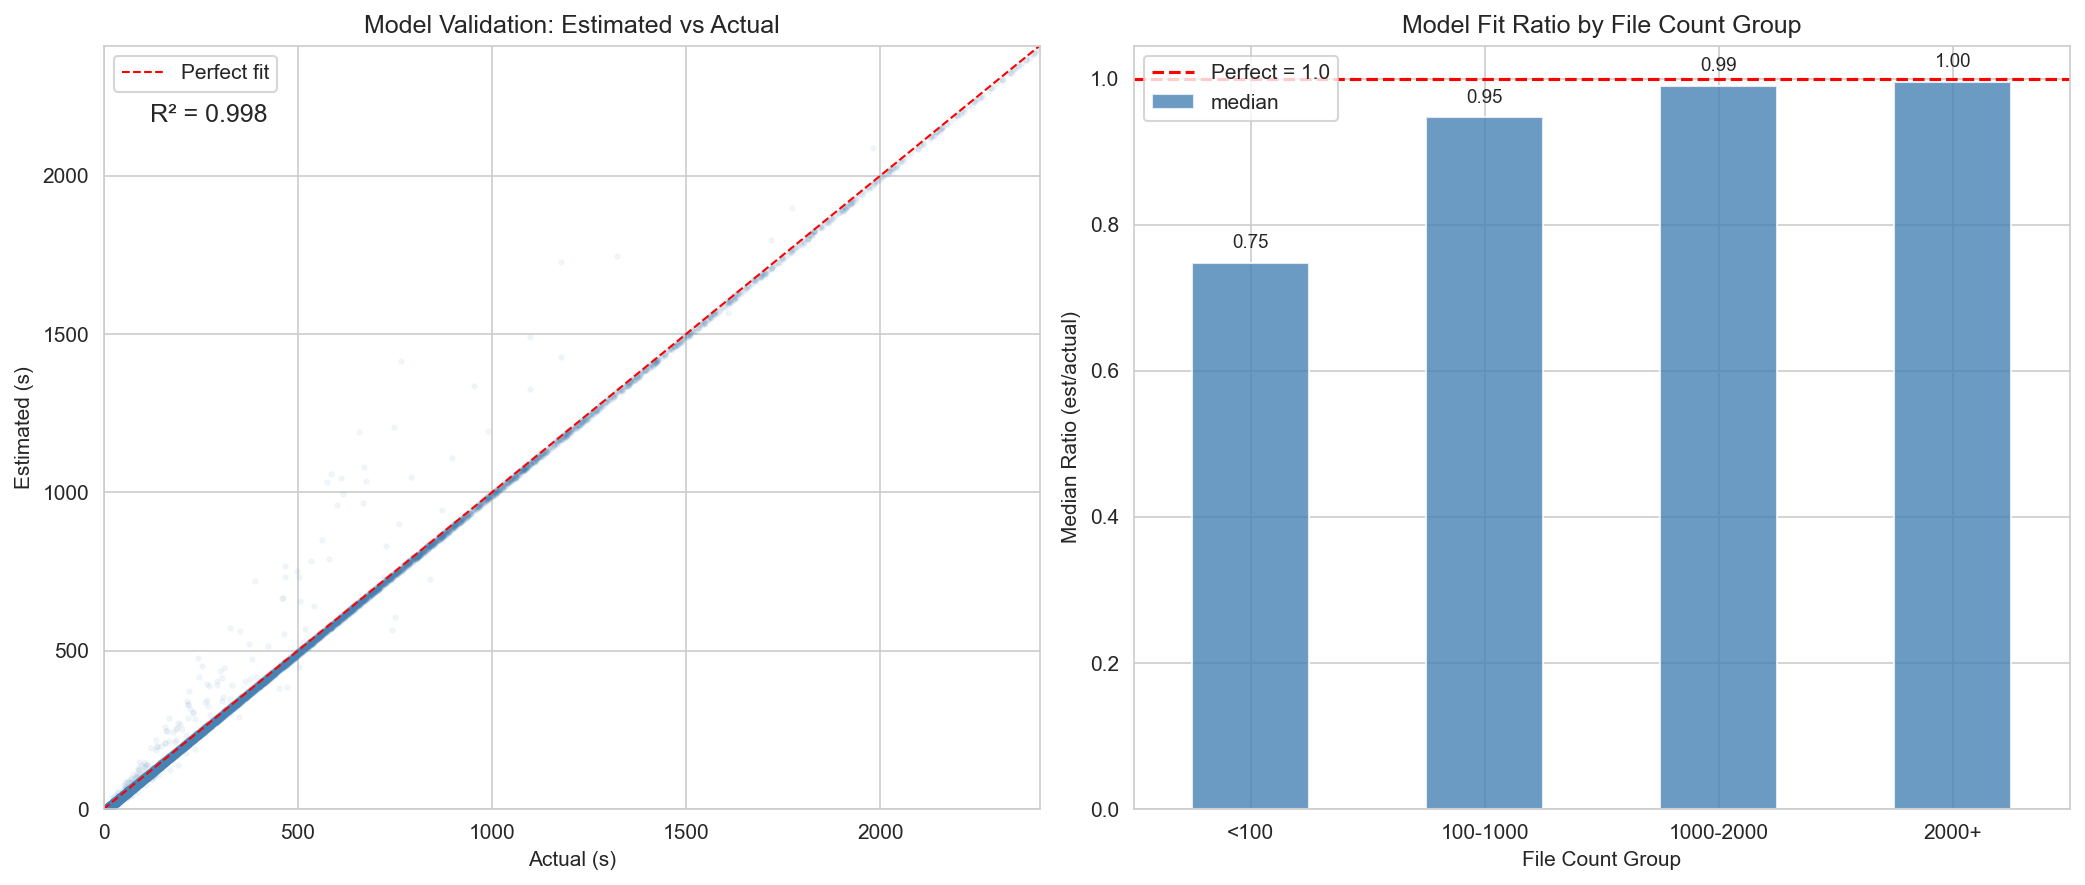


Model R²: 0.998
Ratio by group:
             median      mean  count
fc_group                            
<100       0.748246  0.702055  13184
100-1000   0.947225  0.924304  15067
1000-2000  0.990273  0.989719    865
2000+      0.995894  0.995205    558


In [3]:
# Phase estimation
normal['est_queue'] = normal['queue_duration_seconds']
normal['est_db'] = normal['db_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_device'] = normal['device_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_inner'] = normal['inner_processing_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_total'] = normal['est_queue'] + normal['est_db'] + normal['est_device'] + normal['est_inner']
normal['ratio'] = normal['est_total'] / normal['total_duration_seconds']

normal['fc_group'] = pd.cut(normal['file_count'], bins=FILE_COUNT_BINS, labels=FILE_COUNT_LABELS, right=True)

print("Orders per group:")
print(normal['fc_group'].value_counts().sort_index())

# R²
ss_res = ((normal['est_total'] - normal['total_duration_seconds']) ** 2).sum()
ss_tot = ((normal['total_duration_seconds'] - normal['total_duration_seconds'].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

# Model validation chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
max_val = max(normal['total_duration_seconds'].quantile(0.99), normal['est_total'].quantile(0.99))
ax.scatter(normal['total_duration_seconds'], normal['est_total'], alpha=0.05, s=5, c='steelblue')
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect fit')
ax.set_title('Model Validation: Estimated vs Actual')
ax.set_xlabel('Actual (s)')
ax.set_ylabel('Estimated (s)')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.text(0.05, 0.9, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=12)
ax.legend()

ratio_by_group = normal.groupby('fc_group', observed=True)['ratio'].agg(['median', 'mean', 'count'])
ratio_by_group['median'].plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='Perfect = 1.0')
axes[1].set_title('Model Fit Ratio by File Count Group')
axes[1].set_xlabel('File Count Group')
axes[1].set_ylabel('Median Ratio (est/actual)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
for i, (idx, row) in enumerate(ratio_by_group.iterrows()):
    axes[1].text(i, row['median'] + 0.02, f'{row["median"]:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_model_validation.png', dpi=150)
plt.show()

print(f"\nModel R²: {r2:.3f}")
print(f"Ratio by group:")
print(ratio_by_group.to_string())

if r2 < 0.9:
    print(f"\n⚠️  R² < 0.9，可能 PARALLELISM 不正確，或有未考慮的 overhead")


## Phase Proportion

Phase proportion (%):
           Queue   DB  Device  Inner Processing
fc_group                                       
<100         2.5  2.6    94.5               0.4
100-1000     0.4  2.6    96.6               0.4
1000-2000    0.1  2.3    97.1               0.4
2000+        0.0  2.1    97.5               0.4

Phase absolute means (seconds):
           Queue    DB  Device  Inner Processing
fc_group                                        
<100         0.9   0.9    33.8               0.2
100-1000     0.9   6.2   227.8               1.0
1000-2000    0.9  24.5  1012.6               4.4
2000+        0.9  53.4  2506.0              10.4


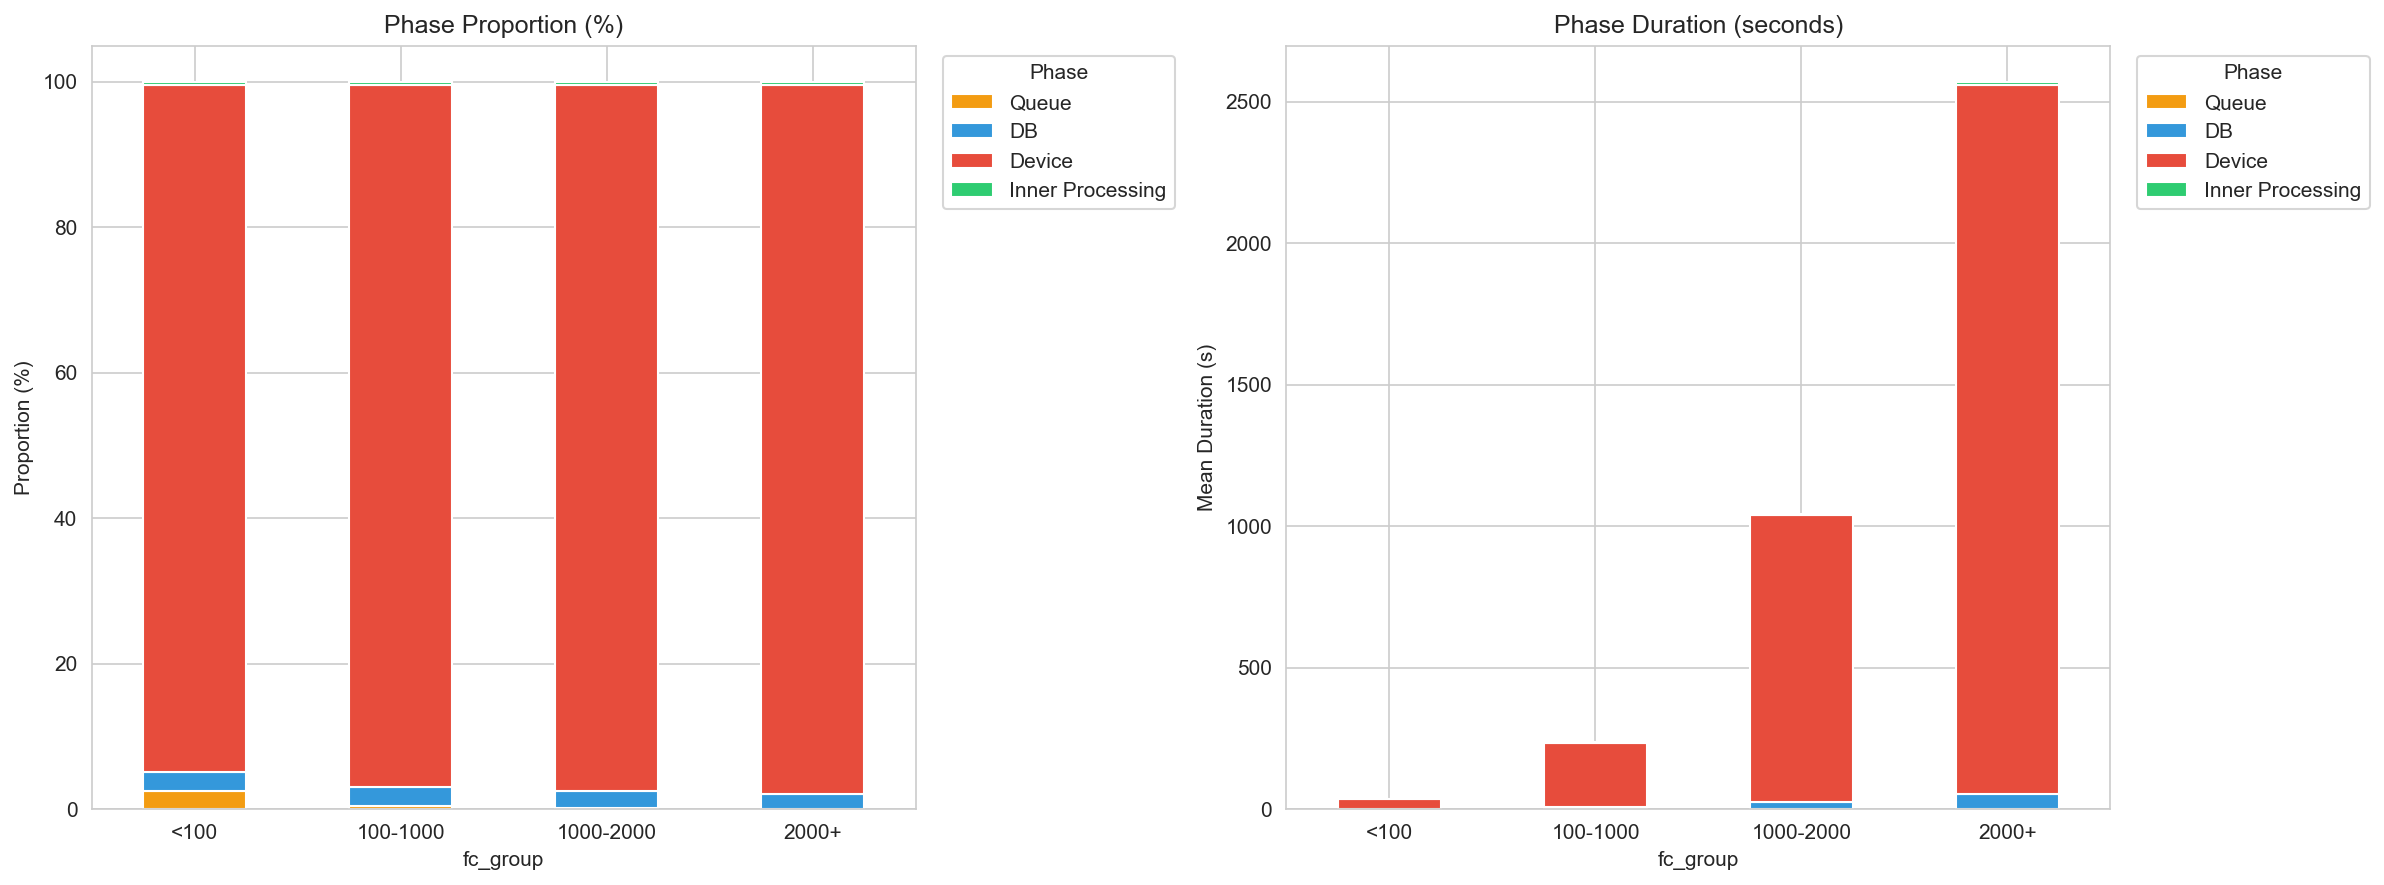

In [4]:
phase_cols = ['est_queue', 'est_db', 'est_device', 'est_inner']
phase_labels = ['Queue', 'DB', 'Device', 'Inner Processing']

group_means = normal.groupby('fc_group', observed=True)[phase_cols].mean()
group_means.columns = phase_labels
group_pct = group_means.div(group_means.sum(axis=1), axis=0) * 100

print("Phase proportion (%):")
print(group_pct.round(1).to_string())
print()
print("Phase absolute means (seconds):")
print(group_means.round(1).to_string())

# Stacked bars
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#f39c12', '#3498db', '#e74c3c', '#2ecc71']

group_pct.plot(kind='bar', stacked=True, ax=axes[0], color=colors)
axes[0].set_title('Phase Proportion (%)')
axes[0].set_ylabel('Proportion (%)')
axes[0].legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

group_means.plot(kind='bar', stacked=True, ax=axes[1], color=colors)
axes[1].set_title('Phase Duration (seconds)')
axes[1].set_ylabel('Mean Duration (s)')
axes[1].legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_phase_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


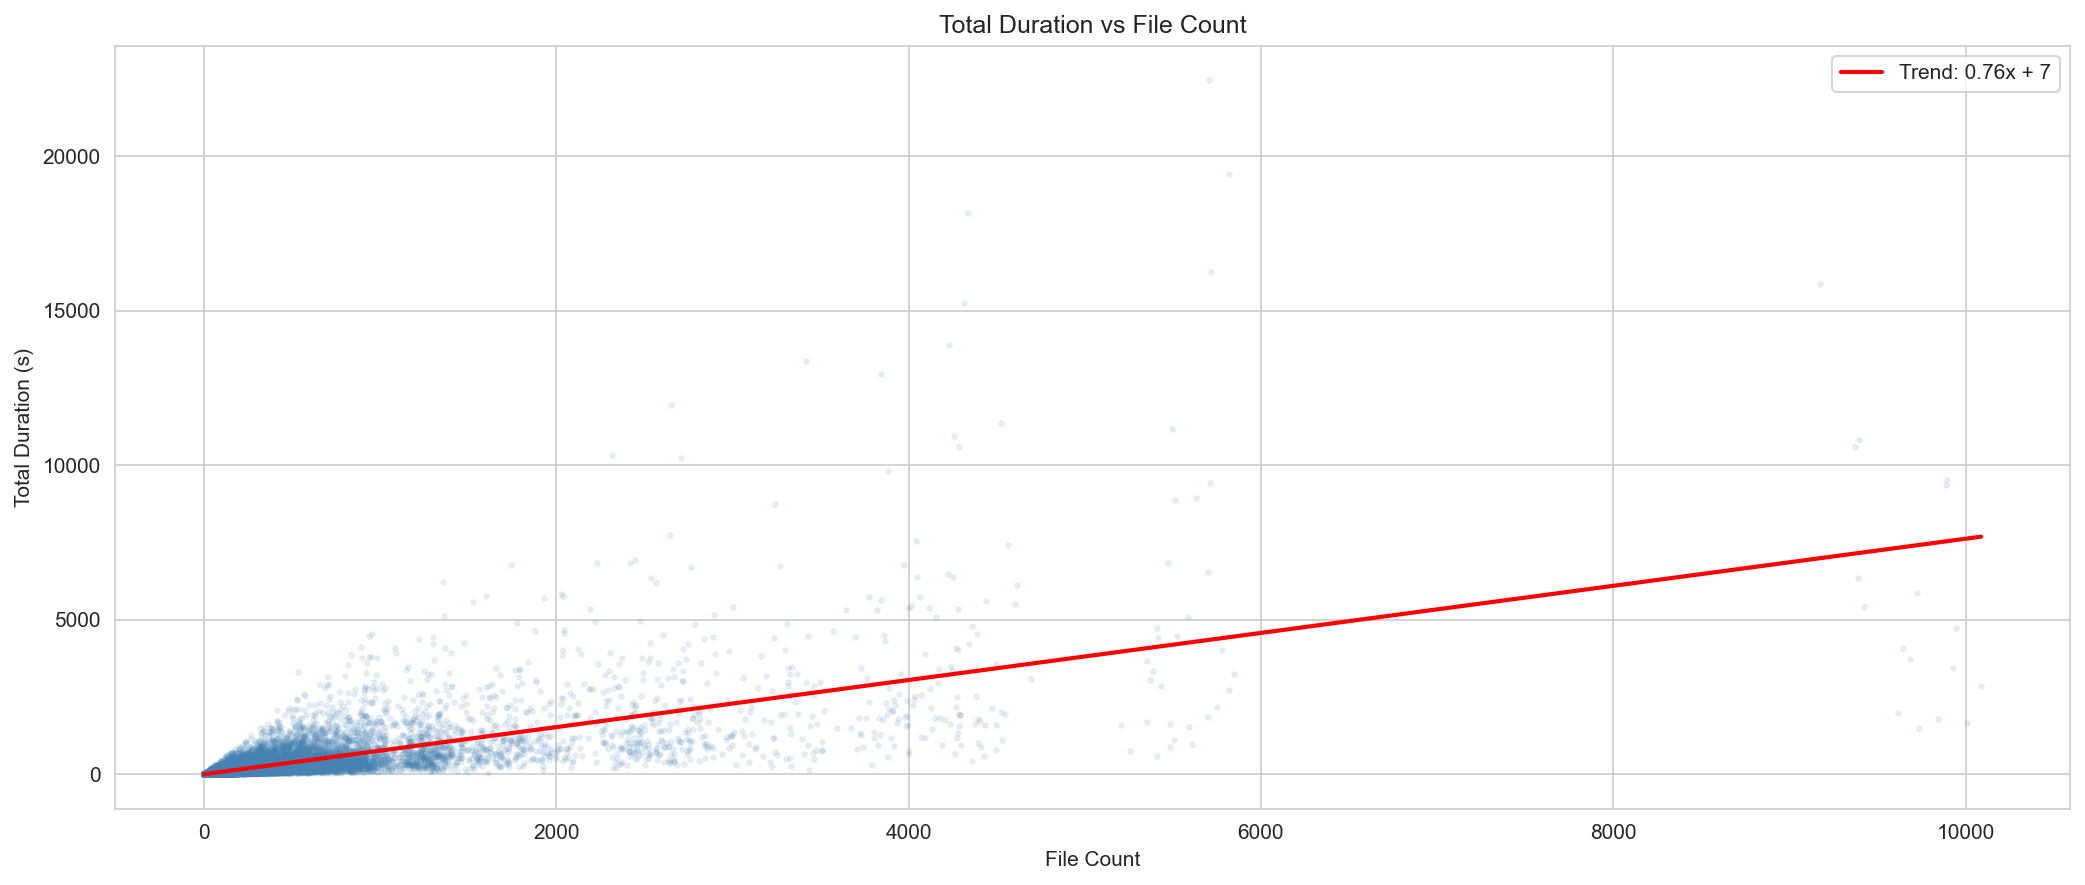

In [5]:
# Duration vs file_count scatter
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(normal['file_count'], normal['total_duration_seconds'], alpha=0.1, s=5, c='steelblue')
z = np.polyfit(normal['file_count'], normal['total_duration_seconds'], 1)
x_line = np.linspace(normal['file_count'].min(), normal['file_count'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2, label=f'Trend: {z[0]:.2f}x + {z[1]:.0f}')
ax.set_title('Total Duration vs File Count')
ax.set_xlabel('File Count')
ax.set_ylabel('Total Duration (s)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_duration_vs_filecount.png', dpi=150)
plt.show()


## Summary

## SLA 達成率分析

按 `SLA_RULES` 定義的目標，計算各規則的 violation rate。

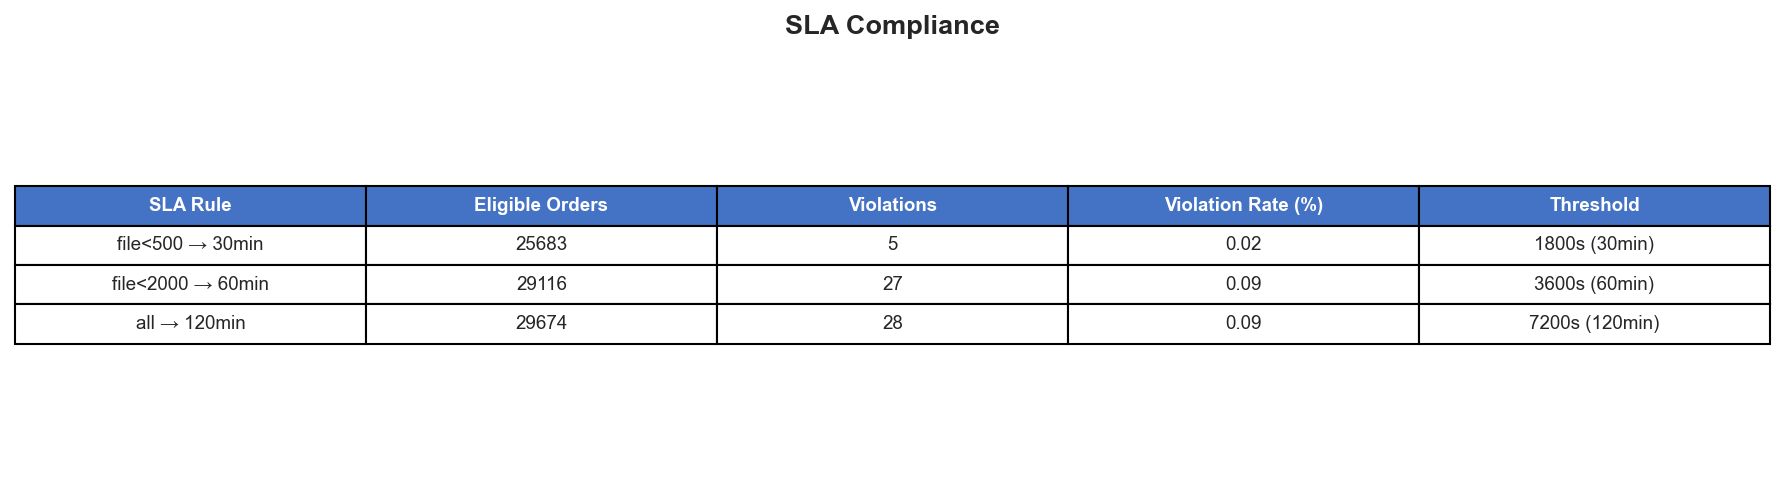

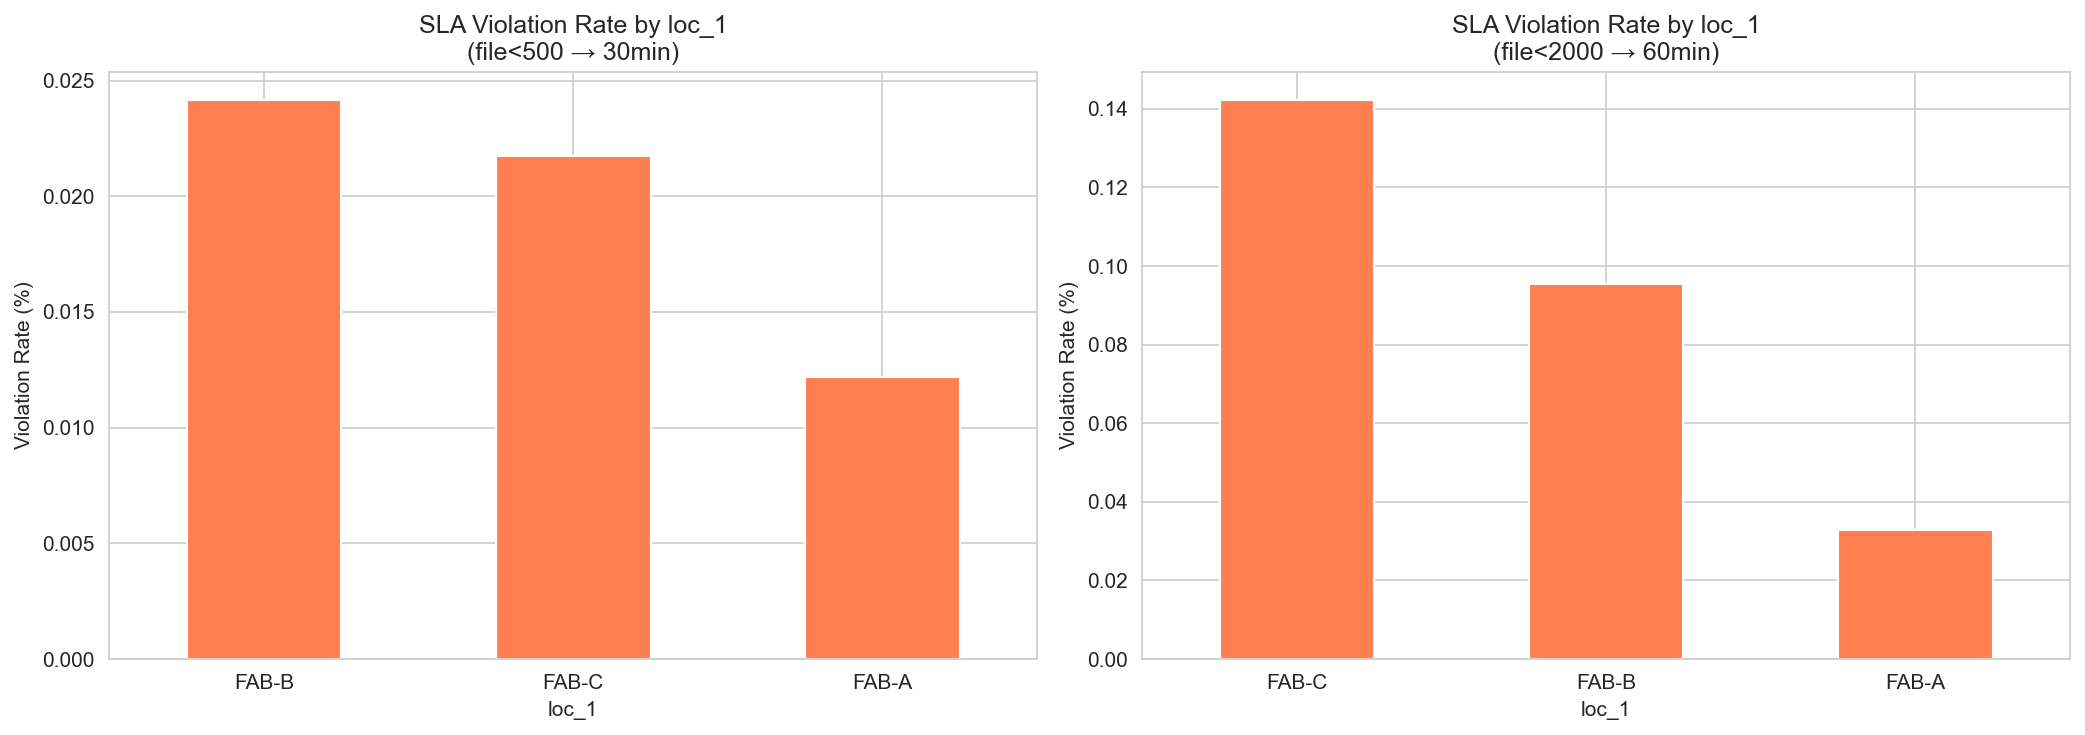

SLA Compliance:
  file<500 → 30min: 0.02% violation (5/25683)
  file<2000 → 60min: 0.09% violation (27/29116)
  all → 120min: 0.09% violation (28/29674)


In [6]:
# SLA compliance analysis
sla_results = []
for max_fc, max_dur, label in SLA_RULES:
    eligible = normal[normal['file_count'] <= max_fc]
    if len(eligible) == 0:
        continue
    violations = eligible[eligible['total_duration_seconds'] > max_dur]
    rate = len(violations) / len(eligible) * 100
    sla_results.append({
        'SLA Rule': label,
        'Eligible Orders': len(eligible),
        'Violations': len(violations),
        'Violation Rate (%)': round(rate, 2),
        'Threshold': f'{max_dur}s ({max_dur//60}min)',
    })

sla_df = pd.DataFrame(sla_results)

# Table image
fig, ax = plt.subplots(figsize=(12, max(2.5, len(sla_df) * 0.6 + 1.5)))
ax.axis('off')
ax.set_title('SLA Compliance', fontsize=13, fontweight='bold', pad=15)
tbl = ax.table(cellText=sla_df.values.tolist(), colLabels=sla_df.columns.tolist(),
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for j in range(len(sla_df.columns)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
# Highlight high violation rates
for r in range(len(sla_df)):
    rate = sla_df.iloc[r]['Violation Rate (%)']
    if rate > 10:
        tbl[r+1, 3].set_facecolor('#FFD7D7')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_sla_compliance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# SLA violation by loc_1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, (max_fc, max_dur, label) in enumerate(SLA_RULES[:2]):
    eligible = normal[normal['file_count'] <= max_fc]
    if len(eligible) == 0:
        continue
    loc_viol = eligible.groupby('loc_1').apply(
        lambda g: (g['total_duration_seconds'] > max_dur).mean() * 100).sort_values(ascending=False)
    loc_viol.plot(kind='bar', ax=axes[ax_idx], color='coral')
    axes[ax_idx].set_title(f'SLA Violation Rate by loc_1\n({label})')
    axes[ax_idx].set_ylabel('Violation Rate (%)')
    axes[ax_idx].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_sla_by_location.png', dpi=150)
plt.show()

print("SLA Compliance:")
for _, row in sla_df.iterrows():
    print(f"  {row['SLA Rule']}: {row['Violation Rate (%)']}% violation ({row['Violations']}/{row['Eligible Orders']})")


## Tail Order 特徵分析

最慢 5% 訂單（P95+）的共同特徵是什麼？

Tail orders (P95+): 1,484 orders, threshold: 845s (14.1min)


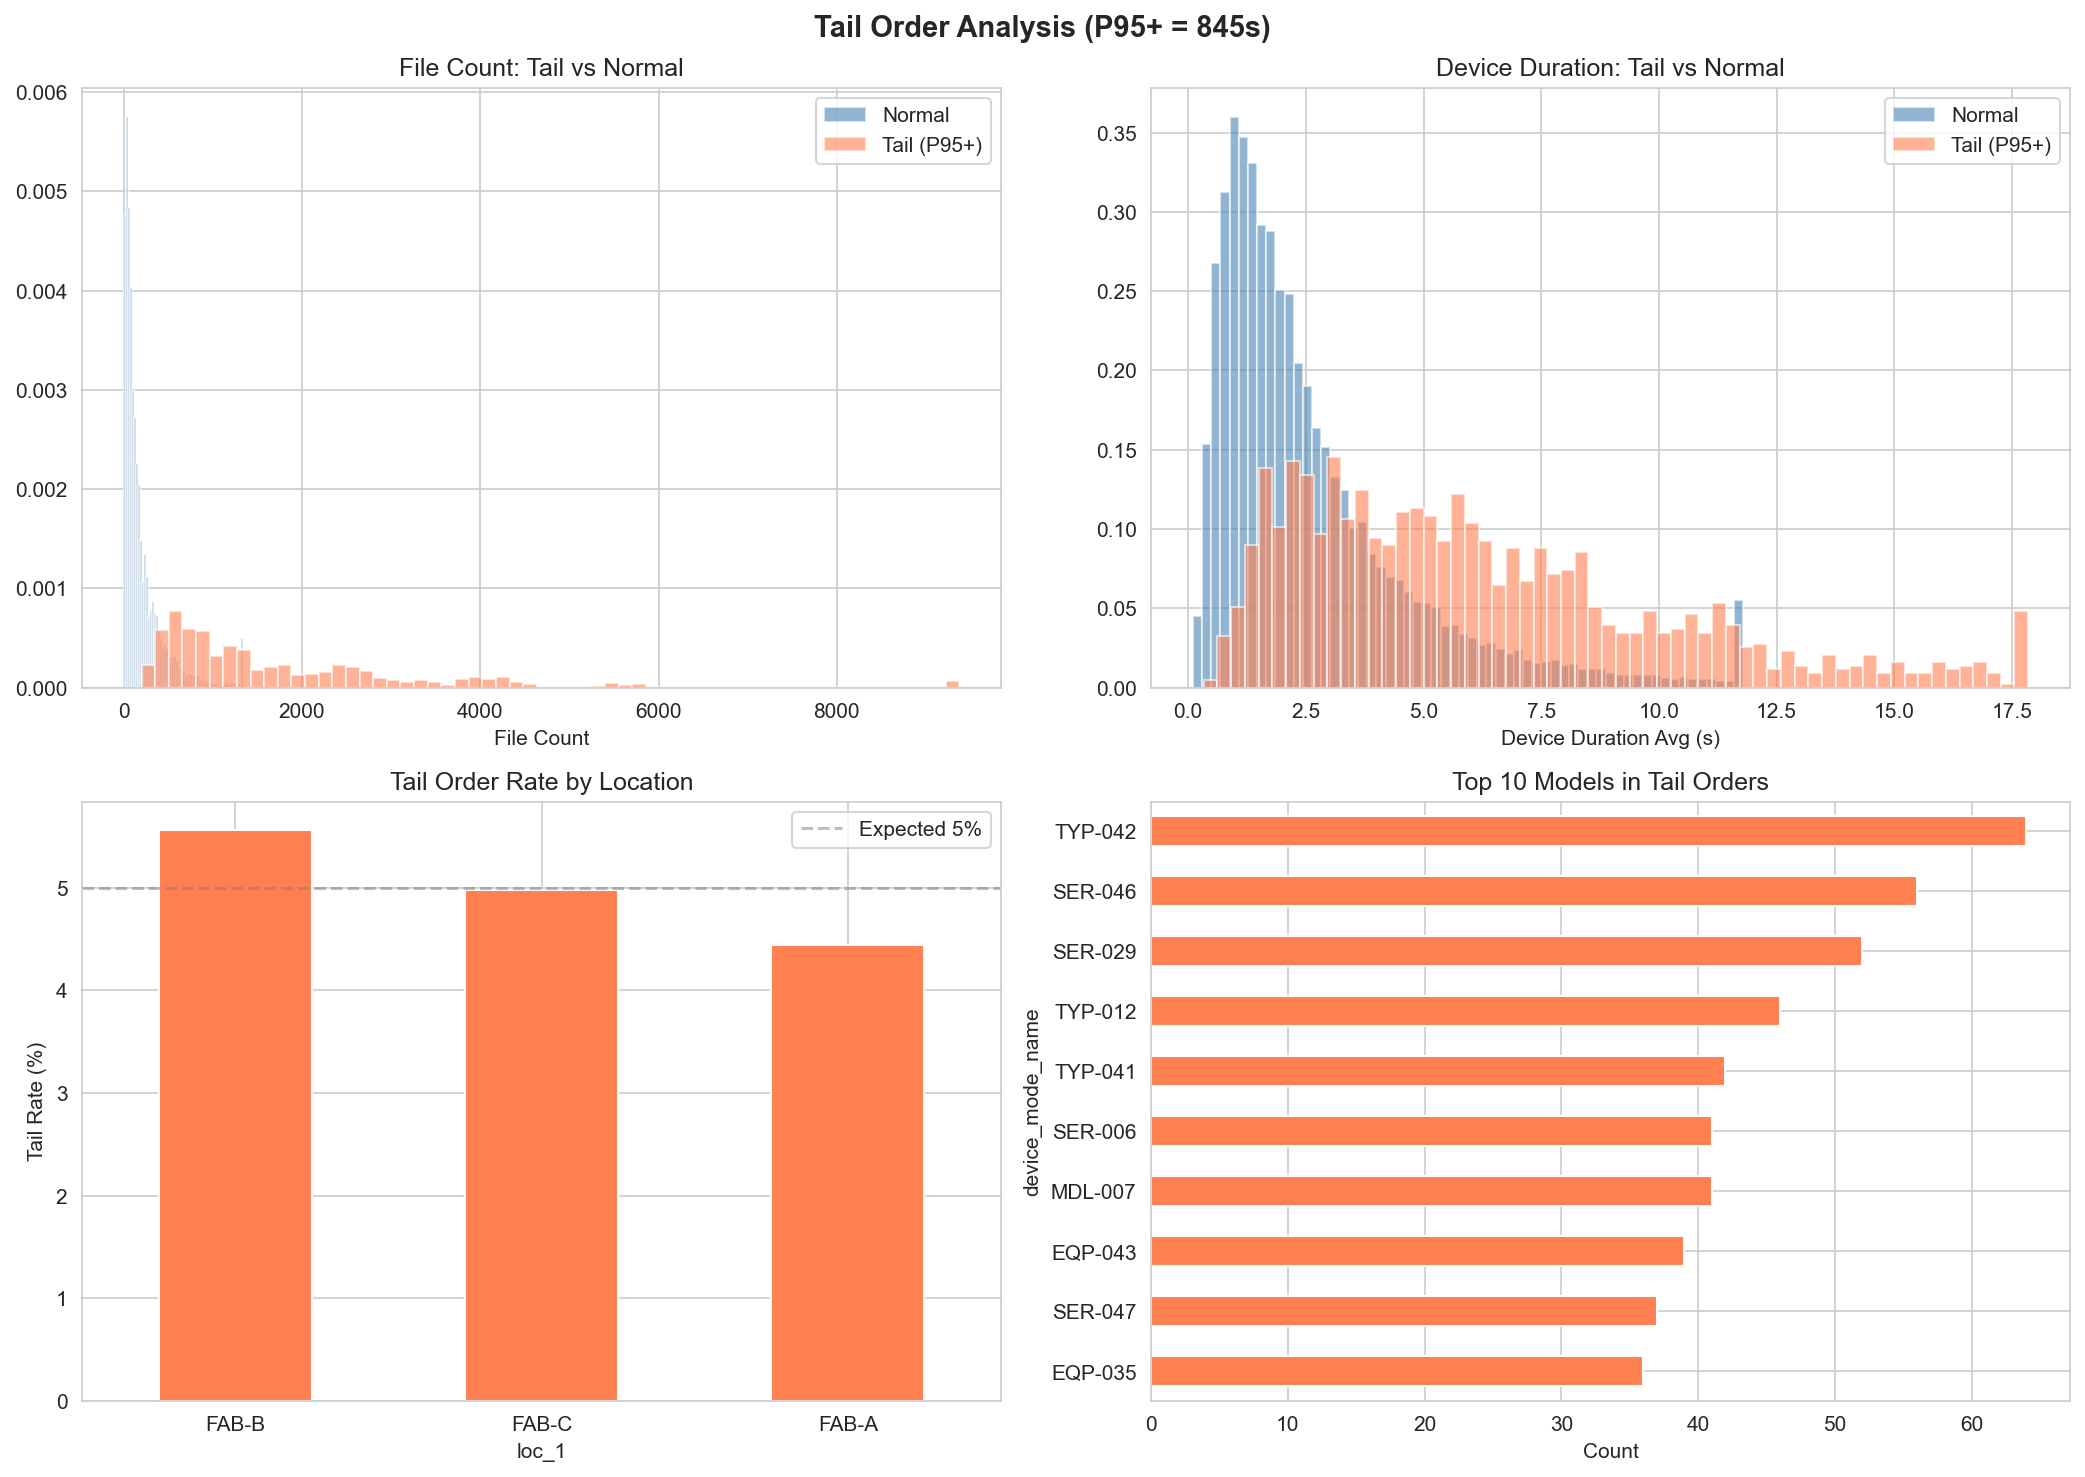


Tail vs Normal comparison:
  file_count: tail P50=1210 vs normal P50=113
  device_dur: tail P50=5.4s vs normal P50=2.0s
  db_dur:     tail P50=0.00s vs normal P50=0.00s


In [7]:
# Tail order analysis (P95+ = slowest 5%)
p95_threshold = normal['total_duration_seconds'].quantile(0.95)
tail = normal[normal['total_duration_seconds'] >= p95_threshold].copy()
non_tail = normal[normal['total_duration_seconds'] < p95_threshold].copy()

print(f"Tail orders (P95+): {len(tail):,} orders, threshold: {p95_threshold:.0f}s ({p95_threshold/60:.1f}min)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# file_count: tail vs normal
axes[0][0].hist(non_tail['file_count'].clip(upper=non_tail['file_count'].quantile(0.99)), 
                bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
axes[0][0].hist(tail['file_count'].clip(upper=tail['file_count'].quantile(0.99)),
                bins=60, alpha=0.6, color='coral', density=True, label='Tail (P95+)')
axes[0][0].set_title('File Count: Tail vs Normal')
axes[0][0].set_xlabel('File Count')
axes[0][0].legend()

# device_duration: tail vs normal
axes[0][1].hist(non_tail['device_duration_avg_seconds'].clip(upper=non_tail['device_duration_avg_seconds'].quantile(0.99)),
                bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
axes[0][1].hist(tail['device_duration_avg_seconds'].clip(upper=tail['device_duration_avg_seconds'].quantile(0.99)),
                bins=60, alpha=0.6, color='coral', density=True, label='Tail (P95+)')
axes[0][1].set_title('Device Duration: Tail vs Normal')
axes[0][1].set_xlabel('Device Duration Avg (s)')
axes[0][1].legend()

# Tail rate by loc_1
tail_by_loc = normal.groupby('loc_1').apply(lambda g: (g['total_duration_seconds'] >= p95_threshold).mean() * 100)
tail_by_loc.sort_values(ascending=False).plot(kind='bar', ax=axes[1][0], color='coral')
axes[1][0].set_title('Tail Order Rate by Location')
axes[1][0].set_ylabel('Tail Rate (%)')
axes[1][0].axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='Expected 5%')
axes[1][0].legend()
axes[1][0].tick_params(axis='x', rotation=0)

# Top 10 device_models contributing most tail orders
tail_models = tail.dropna(subset=['device_mode_name'])
if len(tail_models) > 0:
    model_tail = tail_models['device_mode_name'].value_counts().head(10)
    model_tail.plot(kind='barh', ax=axes[1][1], color='coral')
    axes[1][1].set_title('Top 10 Models in Tail Orders')
    axes[1][1].set_xlabel('Count')
    axes[1][1].invert_yaxis()
else:
    axes[1][1].text(0.5, 0.5, 'No device_mode_name data', ha='center', va='center')
    axes[1][1].set_title('Top Models in Tail Orders')

plt.suptitle(f'Tail Order Analysis (P95+ = {p95_threshold:.0f}s)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_tail_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTail vs Normal comparison:")
print(f"  file_count: tail P50={tail['file_count'].median():.0f} vs normal P50={non_tail['file_count'].median():.0f}")
print(f"  device_dur: tail P50={tail['device_duration_avg_seconds'].median():.1f}s vs normal P50={non_tail['device_duration_avg_seconds'].median():.1f}s")
print(f"  db_dur:     tail P50={tail['db_duration_avg_seconds'].median():.2f}s vs normal P50={non_tail['db_duration_avg_seconds'].median():.2f}s")


In [8]:
biggest = group_pct.idxmax(axis=1)
print("=== Step 3 Summary ===")
print(f"Normal orders: {len(normal):,}")
print(f"Model R²: {r2:.3f}")
print(f"Params: PARALLELISM={PARALLELISM}, bins={FILE_COUNT_BINS}")
print(f"\nDominant phase per group:")
for g, phase in biggest.items():
    print(f"  {g}: {phase} ({group_pct.loc[g, phase]:.1f}%)")
print(f"\nOverall dominant: {group_pct.mean().idxmax()} ({group_pct.mean().max():.1f}% avg)")


=== Step 3 Summary ===
Normal orders: 29,674
Model R²: 0.998
Params: PARALLELISM=4, bins=[0, 100, 1000, 2000, 100000]

Dominant phase per group:
  <100: Device (94.5%)
  100-1000: Device (96.6%)
  1000-2000: Device (97.1%)
  2000+: Device (97.5%)

Overall dominant: Device (96.4% avg)


In [9]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 3 — Bottleneck Breakdown")
summary.append("=" * 60)
summary.append(f"\nNormal orders: {len(normal):,}  （排除異常後的正常訂單數）")
summary.append(f"Model R²: {r2:.3f}  （phase model 的擬合度，>0.9 表示模型有效）")
summary.append(f"PARALLELISM={PARALLELISM}  （每筆 order 的並行 thread 數）")
summary.append(f"FILE_COUNT_BINS={FILE_COUNT_BINS}")
summary.append(f"\n--- Dominant Phase ---  （每個 file_count 組別中，哪個階段佔最大比例）")
for g, phase in biggest.items():
    summary.append(f"  {g}: {phase} ({group_pct.loc[g, phase]:.1f}%)")
summary.append(f"\nOverall dominant: {group_pct.mean().idxmax()} ({group_pct.mean().max():.1f}% avg)")
summary.append(f"  （整體來看佔比最大的階段 → 優化的首要目標）")
summary.append(f"\n--- Phase Proportion (%) ---  （各階段佔 order 總耗時的百分比）")
summary.append(f"  Queue:  等 consumer 撿起訂單的時間")
summary.append(f"  DB:     查詢 golden file list 的時間")
summary.append(f"  Device: 對設備下 command 取得 file 的時間")
summary.append(f"  Inner:  file check 處理時間")
summary.append(group_pct.round(1).to_string())
summary.append(f"\n--- Phase Absolute Means (seconds) ---  （各階段的平均絕對耗時）")
summary.append(group_means.round(1).to_string())

summary.append(f"\n--- SLA Compliance ---")
for _, row in sla_df.iterrows():
    summary.append(f"  {row['SLA Rule']}: {row['Violation Rate (%)']}% violation  （{row['Violations']}/{row['Eligible Orders']} 筆超時）")

summary.append(f"\n--- Tail Order Analysis (P95+) ---")
summary.append(f"  問題：最慢 5% 的訂單為什麼慢？是 file 太多，還是 device 太慢？")
summary.append(f"")
summary.append(f"  Threshold: {p95_threshold:.0f}s ({p95_threshold/60:.1f}min)")
summary.append(f"  Tail orders: {len(tail):,}")
summary.append(f"")

# File count comparison
fc_ratio = tail['file_count'].median() / max(non_tail['file_count'].median(), 1)
summary.append(f"  File Count:     Tail P50={tail['file_count'].median():.0f} vs Normal P50={non_tail['file_count'].median():.0f}  ({fc_ratio:.1f}x)")

# Device duration comparison
dd_ratio = tail['device_duration_avg_seconds'].median() / max(non_tail['device_duration_avg_seconds'].median(), 0.01)
summary.append(f"  Device Duration: Tail P50={tail['device_duration_avg_seconds'].median():.1f}s vs Normal P50={non_tail['device_duration_avg_seconds'].median():.1f}s  ({dd_ratio:.1f}x)")

# DB duration comparison
db_tail_p50 = tail['db_duration_avg_seconds'].median()
db_norm_p50 = non_tail['db_duration_avg_seconds'].median()
summary.append(f"  DB Duration:    Tail P50={db_tail_p50:.2f}s vs Normal P50={db_norm_p50:.2f}s")

summary.append(f"")
summary.append(f"  解讀（看圖 step3_tail_analysis.png 的左上+右上）：")
summary.append(f"    橘色(tail) vs 藍色(normal) 的 density histogram：")
summary.append(f"    - 橘色明顯偏右 = 該因素是慢的主因")
summary.append(f"    - 兩色重疊 = 該因素不是主因")
summary.append(f"")

# Auto-generate conclusion
factors = []
if fc_ratio > 3:
    factors.append(f"file 數量（{fc_ratio:.0f}x）")
if dd_ratio > 2:
    factors.append(f"device 速度（{dd_ratio:.1f}x）")
if factors:
    summary.append(f"  結論：慢訂單主因是 {' + '.join(factors)}")
else:
    summary.append(f"  結論：file_count 和 device_duration 差異不大，慢訂單可能由多因素共同造成")

# Location tail rate
tail_by_loc = normal.groupby('loc_1').apply(lambda g: (g['total_duration_seconds'] >= p95_threshold).mean() * 100)
loc_max = tail_by_loc.idxmax()
loc_min = tail_by_loc.idxmin()
summary.append(f"")
summary.append(f"  Location tail rate: {loc_max}={tail_by_loc[loc_max]:.1f}% (最高), {loc_min}={tail_by_loc[loc_min]:.1f}% (最低)")
if tail_by_loc.max() / max(tail_by_loc.min(), 0.1) > 1.5:
    summary.append(f"    ⚠️ Location 間有顯著差異 → {loc_max} 需要關注")
else:
    summary.append(f"    各 location 差異不大（均勻分佈）")

with open(str(REPORTS_DIR / 'step3_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step3_summary.txt")


Saved: reports/step3_summary.txt
